# Simulation Example Notebook

This is an example of how to use the stacking and reclaiming simulation of bulk material homogenization using the `simple` helper module. The module uses default values for many variables and can be used as a template for more complex simulations. This notebook also demonstrates how reclaimed material can be evaluated.

In [1]:
# Import the helper module
from bmh.helpers import simple

In [2]:
# Define the size of the blending bed (system parameter)
bed_size_x = 300
bed_size_z = 50

# Define the list of qualities and total volume of the material (specific to the problem instance)
quality = [1, 5, 3, 10, 5, 8, 3, 9, 3, 1]
total_volume = 100000

# Define the list of positions where the material will be deposited (optimization variable)
position = [140, 25, 275, 150, 275, 25, 150]

In [3]:
# Convert variables into material deposition
material_deposition = simple.generate_material_deposition(
    quality=quality, total_volume=total_volume, x_position=position, bed_size_x=bed_size_x, bed_size_z=bed_size_z
)

In [4]:
# Simulate material deposition creating reclaimed material
reclaimed_material = simple.bsl_stack_reclaim(material_deposition)
reclaimed_material.data

,x,volume,quality,timestamp
0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,288.0
2,2.0,0.0,0.0,576.0
3,3.0,0.0,0.0,864.0
4,4.0,0.0,0.0,1152.0
...,...,...,...,...
296,296.0,0.0,0.0,85248.0
297,297.0,0.0,0.0,85536.0
298,298.0,0.0,0.0,85824.0
299,299.0,0.0,0.0,86112.0


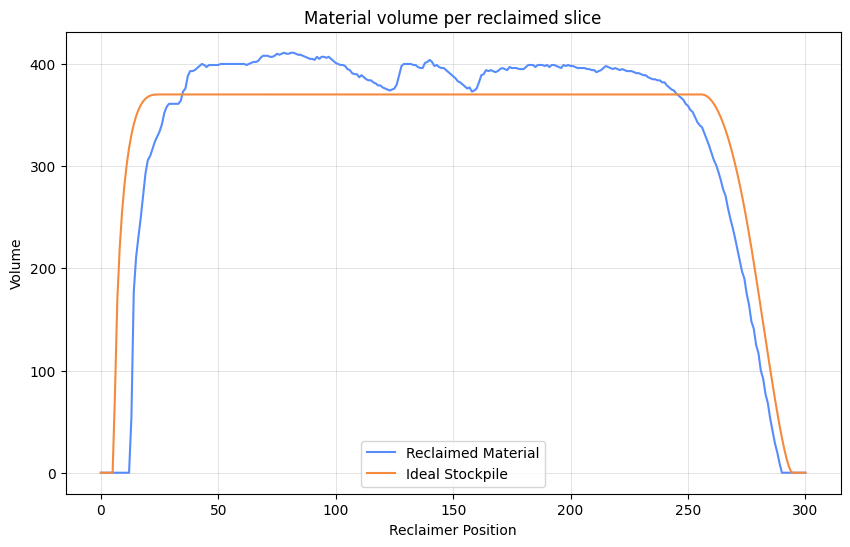

In [5]:
# Visualize reclaimed material volume vs. ideal stockpile volume
import matplotlib.pyplot as plt
from bmh.helpers.stockpile_math import get_ideal_stockpile_volumes

# The minimum and maximum x-positions of the stacker are set to have the same distance from the borders in x-direction as they have
# from the borders in the z-direction when centered in the blending bed.
x_min = 0.5 * bed_size_z
x_max = bed_size_x - 0.5 * bed_size_z

ideal_stockpile_volume = get_ideal_stockpile_volumes(x=reclaimed_material.data["x"], volume=total_volume, x_min=x_min, x_max=x_max)

plt.figure(figsize=(10, 6))
plt.plot(reclaimed_material.data["x"], reclaimed_material.data["volume"], label="Reclaimed Material")
plt.plot(reclaimed_material.data["x"], ideal_stockpile_volume, label="Ideal Stockpile")
plt.xlabel("Reclaimer Position")
plt.ylabel("Volume")
plt.title("Material volume per reclaimed slice")
plt.grid(True)
plt.legend()
plt.show()

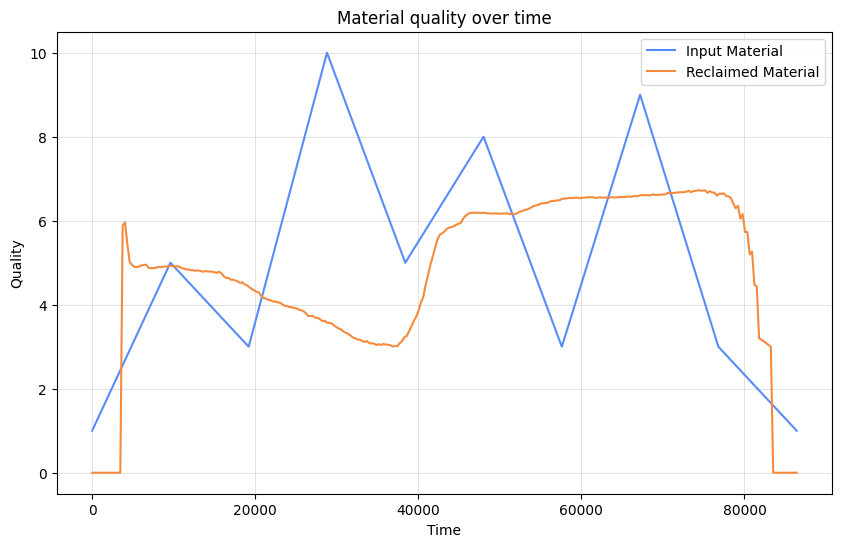

In [6]:
# Visualize the material quality curve of input vs. reclaimed material
plt.figure(figsize=(10, 6))
plt.plot(material_deposition.material.data["timestamp"], material_deposition.material.data["quality"], label="Input Material")
plt.plot(reclaimed_material.data["timestamp"], reclaimed_material.data["quality"], label="Reclaimed Material")
plt.xlabel("Time")
plt.ylabel("Quality")
plt.title("Material quality over time")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Evaluate reclaimed material
from bmh.helpers.reclaimed_material_evaluator import ReclaimedMaterialEvaluator

evaluator = ReclaimedMaterialEvaluator(reclaimed=reclaimed_material, x_min=x_min, x_max=x_max)
f1 = evaluator.get_single_parameter_stdev("quality")
f2 = evaluator.get_volume_stdev()

print(f"Objective F1: {f1:.2f}")
print(f"Objective F2: {f2:.2f}")

Objective F1: 1.26
Objective F2: 53.77
